# 2 — Simple model: NARX-MLP (8, 8) — train, validate, submit

Self-contained notebook for the **simple approach** of the ANN assignment.

**What this notebook does**, in order:
1. Trains a NARX-MLP with `(n_a=8, n_b=8)` on the processed signals from `1_data_prep.ipynb`.
2. Saves the trained weights to `artifacts/best_narx.pt`.
3. Validates the model on the 20% temporal validation split, in both **prediction** and **simulation** (free-run) modes.
4. Generates the two `.npz` submission files (`narx-mlp-prediction-*` and `narx-mlp-simulation-*`).
5. Runs the official `submission-file-checker.py` to validate the format.

## Why `(n_a=8, n_b=8)`?

In `exploration/1_narx_grid_ranked-on-prediction-only.ipynb` we tried the full grid `(n_a, n_b) ∈ {2,4,6,8}²` and ranked the 16 models on **prediction** RMSE only — the winner was `(4, 6)`.

In `exploration/2_narx_grid_ranked-on-prediction+simulation.ipynb` we re-ranked the same 16 models also on **simulation** RMSE and uncovered a clear Pareto trade-off:
- `(4, 6)` is PRED-optimal (~0.005 rad) but mediocre in SIM (~0.149 rad).
- `(8, 8)` is SIM-optimal (~0.116 rad, -22% vs (4,6)) **and** minimizes the balanced PRED+SIM score, with PRED ~0.0066 rad still on par with the repo's Linear ARX baseline (0.00665 rad).

So `(8, 8)` is a more representative "simple-NARX" model for the Unbalanced Disc: small PRED penalty for a substantial SIM gain.

## Architecture & training recipe

- MLP `64 → 64 → 2` with `tanh` activations.
- Input regressor (`u`-first ordering, compatible with the repo example scripts):
  $$\varphi_k = [\,u_{k-n_b}, \dots, u_{k-1},\, \sin\theta_{k-n_a}, \cos\theta_{k-n_a}, \dots, \sin\theta_{k-1}, \cos\theta_{k-1}\,]$$
- Target: $(\sin\theta_k, \cos\theta_k)$, recovered as $\hat\theta_k = \mathrm{atan2}(\hat s_k, \hat c_k)$.
- Loss: MSE on $(\sin, \cos)$.
- Optimizer: Adam, `lr=1e-3`, `weight_decay=1e-5`.
- LR scheduler: ReduceLROnPlateau (factor 1/3, patience 5).
- Early stopping: patience 15, max 200 epochs.


## 2.1 — Setup

In [23]:
import time, math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

REPO_DIR  = Path('/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/gym-unbalanced-disk-master/disc-benchmark-files')
WORK_DIR  = Path('/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment')
ARTIFACTS = WORK_DIR / 'artifacts'
SUBMISSIONS = WORK_DIR / 'submissions'
SUBMISSIONS.mkdir(exist_ok=True)

NA, NB = 8, 8
HIDDEN = 64
U_SCALE = 3.0

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0)
print(f'device: {device}    target architecture: NARX-MLP na={NA}, nb={NB}, hidden={HIDDEN}')


device: mps    target architecture: NARX-MLP na=8, nb=8, hidden=64


## 2.2 — Load processed signals from `1_data_prep.ipynb`

In [24]:
P = np.load(ARTIFACTS / 'step2_processed.npz')
u_tr_n, u_va_n = P['u_tr_n'], P['u_va_n']
sin_tr, cos_tr = P['sin_tr'], P['cos_tr']
sin_va, cos_va = P['sin_va'], P['cos_va']
th_tr,  th_va  = P['th_tr'],  P['th_va']
print(f'Train: {len(u_tr_n)} samples   Val: {len(u_va_n)} samples')


Train: 28000 samples   Val: 7000 samples


## 2.3 — Model definition and helpers

In [25]:
class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

def create_IO_data_sincos(u_n, sin_th, cos_th, na, nb):
    n0 = max(na, nb); N = len(u_n); M = N - n0
    idx_u  = np.arange(M)[:, None] + np.arange(n0 - nb, n0)
    idx_th = np.arange(M)[:, None] + np.arange(n0 - na, n0)
    Xu = u_n[idx_u]; Xs = sin_th[idx_th]; Xc = cos_th[idx_th]
    Xsc = np.empty((M, 2*na), dtype=Xu.dtype)
    Xsc[:, 0::2] = Xs; Xsc[:, 1::2] = Xc
    X = np.concatenate([Xu, Xsc], axis=1).astype(np.float32)
    Y = np.stack([sin_th[n0:], cos_th[n0:]], axis=1).astype(np.float32)
    return X, Y

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


## 2.4 — Train the NARX (8, 8)

Standard supervised training in **prediction** mode (teacher forcing): the network always
receives true past values of `u` and `θ` as input. The exposure-bias gap (worse simulation
than prediction) is the motivation for the advanced model in `3_lstm_advanced.ipynb`.


in_dim = nb + 2*na = 24   train pairs: 27992   val pairs: 6992
Trained in 46.6s    epochs=175    best val MSE=3.6730e-05


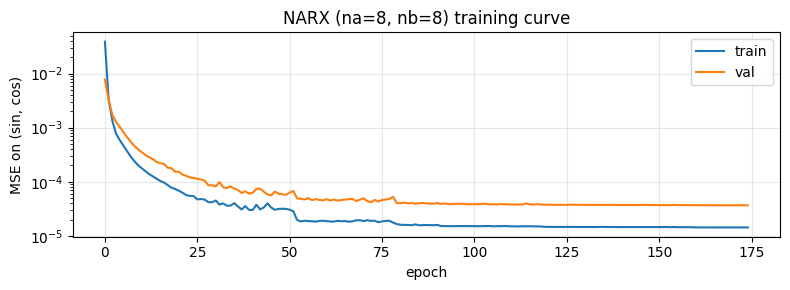

In [26]:
Xtr, Ytr = create_IO_data_sincos(u_tr_n, sin_tr, cos_tr, NA, NB)
Xva, Yva = create_IO_data_sincos(u_va_n, sin_va, cos_va, NA, NB)
IN_DIM = Xtr.shape[1]
print(f'in_dim = nb + 2*na = {IN_DIM}   train pairs: {Xtr.shape[0]}   val pairs: {Xva.shape[0]}')

Xtr_t = torch.from_numpy(Xtr).to(device); Ytr_t = torch.from_numpy(Ytr).to(device)
Xva_t = torch.from_numpy(Xva).to(device); Yva_t = torch.from_numpy(Yva).to(device)
loader = DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=256, shuffle=True)

model = NARX_MLP(IN_DIM, hidden=HIDDEN).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=5)
loss_fn = nn.MSELoss()

best_val = float('inf'); best_state = None; bad = 0
patience = 15; max_epochs = 200
history = {'train': [], 'val': []}

t0 = time.time()
for epoch in range(1, max_epochs + 1):
    model.train()
    ep_loss = 0.0; n = 0
    for xb, yb in loader:
        opt.zero_grad()
        l = loss_fn(model(xb), yb)
        l.backward(); opt.step()
        ep_loss += l.item() * xb.size(0); n += xb.size(0)
    train_loss = ep_loss / n
    model.eval()
    with torch.no_grad():
        v = loss_fn(model(Xva_t), Yva_t).item()
    sched.step(v)
    history['train'].append(train_loss); history['val'].append(v)
    if v < best_val - 1e-7:
        best_val = v
        best_state = {k: vv.detach().clone() for k, vv in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience: break

model.load_state_dict(best_state)
print(f'Trained in {time.time()-t0:.1f}s    epochs={epoch}    best val MSE={best_val:.4e}')

# Training curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history['train'], label='train')
ax.semilogy(history['val'],   label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE on (sin, cos)'); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f'NARX (na={NA}, nb={NB}) training curve')
plt.tight_layout(); plt.show()


## 2.5 — Validate in **prediction** and **simulation** mode

In [27]:
@torch.no_grad()
def f_pred_batch(phi_np):
    x = torch.from_numpy(phi_np.astype(np.float32)).to(device)
    return model(x).cpu().numpy()

# Prediction self-check.
Yhat = f_pred_batch(Xva)
th_hat = np.arctan2(Yhat[:, 0], Yhat[:, 1])
th_true = th_va[max(NA, NB):]
err_pred = wrap_pi(th_hat - th_true)
val_pred = float(np.sqrt(np.mean(err_pred ** 2)))
print(f'Val PREDICTION  RMSE_theta = {val_pred:.4f} rad  ({math.degrees(val_pred):.3f}\u00b0)')


Val PREDICTION  RMSE_theta = 0.0068 rad  (0.387°)


Val SIMULATION  RMSE_theta = 0.1221 rad  (6.996°)


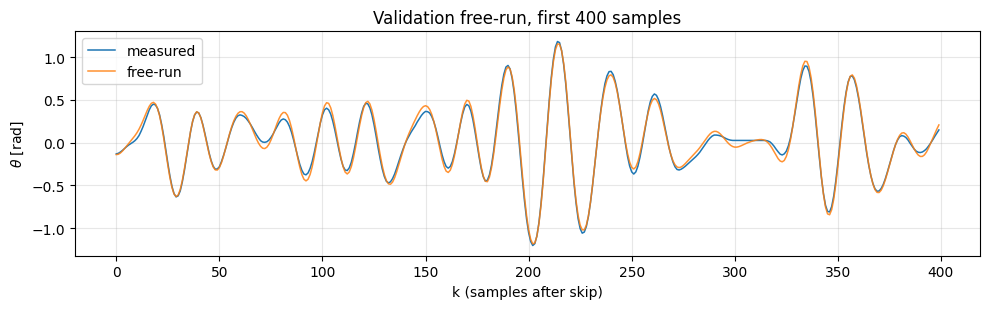

In [28]:
def build_phi(u_past, sin_past, cos_past, na, nb):
    u_arr = np.asarray(u_past, dtype=np.float32)
    s_arr = np.asarray(sin_past, dtype=np.float32)
    c_arr = np.asarray(cos_past, dtype=np.float32)
    sc = np.empty(2 * na, dtype=np.float32)
    sc[0::2] = s_arr; sc[1::2] = c_arr
    return np.concatenate([u_arr, sc])[None, :]

def simulate_freerun(u_seq_n, sin_seed, cos_seed, na, nb, skip):
    N = len(u_seq_n)
    sin_sim = np.zeros(N, dtype=np.float32); cos_sim = np.zeros(N, dtype=np.float32)
    sin_sim[:skip] = sin_seed[:skip]; cos_sim[:skip] = cos_seed[:skip]
    u_buf = list(u_seq_n[skip-nb:skip].astype(np.float32))
    s_buf = list(sin_sim[skip-na:skip])
    c_buf = list(cos_sim[skip-na:skip])
    for k in range(skip, N):
        phi = build_phi(u_buf, s_buf, c_buf, na, nb)
        yhat = f_pred_batch(phi)[0]
        s_hat, c_hat = float(yhat[0]), float(yhat[1])
        sin_sim[k] = s_hat; cos_sim[k] = c_hat
        u_buf.append(float(u_seq_n[k])); u_buf.pop(0)
        s_buf.append(s_hat); s_buf.pop(0)
        c_buf.append(c_hat); c_buf.pop(0)
    return np.arctan2(sin_sim, cos_sim), sin_sim, cos_sim

skip = max(NA, NB)
th_sim_val, _, _ = simulate_freerun(u_va_n, sin_va, cos_va, NA, NB, skip=skip)
err_sim = wrap_pi(th_sim_val[skip:] - th_va[skip:])
val_sim = float(np.sqrt(np.mean(err_sim ** 2)))
print(f'Val SIMULATION  RMSE_theta = {val_sim:.4f} rad  ({math.degrees(val_sim):.3f}\u00b0)')

# Visual check.
n_show = 400
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(th_va[skip:skip+n_show],   label='measured', lw=1.1)
ax.plot(th_sim_val[skip:skip+n_show], label='free-run', lw=1.1, alpha=0.85)
ax.set_xlabel('k (samples after skip)'); ax.set_ylabel(r'$\theta$ [rad]'); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f'Validation free-run, first {n_show} samples')
plt.tight_layout(); plt.show()


## 2.6 — Save the trained model

In [29]:
torch.save({
    'state_dict': best_state,
    'na': NA, 'nb': NB, 'in_dim': IN_DIM, 'hidden': HIDDEN,
    'U_SCALE': U_SCALE,
    'val_rmse_theta_rad': val_pred,
    'val_pred_rad': val_pred,
    'val_sim_rad':  val_sim,
    'selection_criterion': 'balanced PRED+SIM (Pareto analysis on the 4x4 grid)',
}, ARTIFACTS / 'best_narx.pt')
print(f'Saved {ARTIFACTS / "best_narx.pt"}')


Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/artifacts/best_narx.pt


## 2.7 — Generate the **prediction** submission

The file `hidden-test-prediction-submission-file.npz` provides for each row $k$ the 15 most recent inputs and outputs:
```
upast[k]  = [ u[k-15], ..., u[k-1] ]
thpast[k] = [ θ[k-15], ..., θ[k-1] ]
```
We extract the last $n_b$ inputs and last $n_a$ angles, build $\varphi_k$, predict $(\sin\theta_k, \cos\theta_k)$ and recover $\hat\theta_k = \mathrm{atan2}$.


In [30]:
test_pred = np.load(REPO_DIR / 'hidden-test-prediction-submission-file.npz')
upast  = test_pred['upast']; thpast = test_pred['thpast']
N_test = upast.shape[0]
u_win  = (upast[:, -NB:] / U_SCALE).astype(np.float32)
th_win = thpast[:, -NA:]
sin_w  = np.sin(th_win).astype(np.float32); cos_w = np.cos(th_win).astype(np.float32)
sc = np.empty((N_test, 2 * NA), dtype=np.float32)
sc[:, 0::2] = sin_w; sc[:, 1::2] = cos_w
Phi_test = np.concatenate([u_win, sc], axis=1)
with torch.no_grad():
    Y = model(torch.from_numpy(Phi_test).to(device)).cpu().numpy()
th_pred_test = np.arctan2(Y[:, 0], Y[:, 1])
out_pred = SUBMISSIONS / 'narx-mlp-prediction-submission-file.npz'
np.savez(out_pred, upast=upast, thpast=thpast, thnow=th_pred_test)
print(f'Saved {out_pred}    th_pred range: [{th_pred_test.min():.3f}, {th_pred_test.max():.3f}]')


Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/narx-mlp-prediction-submission-file.npz    th_pred range: [-1.500, 1.563]


## 2.8 — Generate the **simulation** submission

Free-run from sample 50 (seed) to 5000 driven by the test input sequence.


In [31]:
test_sim = np.load(REPO_DIR / 'hidden-test-simulation-submission-file.npz')
u_sim_raw = test_sim['u']; th_sim_seed = test_sim['th'].copy()
u_sim_n = (u_sim_raw / U_SCALE).astype(np.float32)
sin_seed = np.sin(th_sim_seed).astype(np.float32)
cos_seed = np.cos(th_sim_seed).astype(np.float32)
skip_sim = 50
th_sim_full, _, _ = simulate_freerun(u_sim_n, sin_seed, cos_seed, NA, NB, skip=skip_sim)
th_sim_full[:skip_sim] = th_sim_seed[:skip_sim]
out_sim = SUBMISSIONS / 'narx-mlp-simulation-submission-file.npz'
np.savez(out_sim, th=th_sim_full, u=u_sim_raw)
print(f'Saved {out_sim}    th_sim range: [{th_sim_full.min():.3f}, {th_sim_full.max():.3f}]')


Saved /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/narx-mlp-simulation-submission-file.npz    th_sim range: [-1.632, 1.889]


## 2.9 — Format check with the official `submission-file-checker.py`

This only validates the **format** (shape, keys). The reported RMSE is meaningless here
because the solution file is the zero-filled hidden test file; the real RMSE on the hidden
ground truth can only be computed by the lecturers.


In [32]:
import subprocess, sys, os
checker = REPO_DIR / 'submission-file-checker.py'
for sub, sol in [
    (out_pred, REPO_DIR / 'hidden-test-prediction-submission-file.npz'),
    (out_sim,  REPO_DIR / 'hidden-test-simulation-submission-file.npz'),
]:
    print(f'\n--- checking {sub.name} ---')
    res = subprocess.run([sys.executable, str(checker), str(sub), str(sol)],
                         capture_output=True, text=True,
                         env={**os.environ, 'MPLBACKEND': 'Agg'})
    print('STDOUT:', res.stdout.strip())
    if res.returncode != 0:
        print('STDERR:', res.stderr.strip())



--- checking narx-mlp-prediction-submission-file.npz ---
STDOUT: ################ Prediction Result ##################
RMS= 0.5162 radians
RMS= 29.574 degrees
NRMS= inf%

--- checking narx-mlp-simulation-submission-file.npz ---
STDOUT: ################ Simulation Result ##################
RMS= 0.5331 radians
RMS= 30.544 degrees
NRMS= 1619.41%


## 2.10 — Summary

In [33]:
print('==============  NARX-MLP (simple model)  ==============')
print(f'Architecture : MLP({IN_DIM}, {HIDDEN}, {HIDDEN}, 2)  tanh,  na={NA}, nb={NB}')
print(f'Val PRED RMSE_theta = {val_pred:.4f} rad   ({math.degrees(val_pred):.3f}\u00b0)')
print(f'Val SIM  RMSE_theta = {val_sim:.4f} rad   ({math.degrees(val_sim):.3f}\u00b0)')
print(f'\nReference baselines (from repo README):')
print(f'  Linear ARX prediction   = 0.00665 rad (0.381\u00b0)')
print(f'  Good NN  prediction     = 0.00382 rad (0.219\u00b0)')
print(f'  Linear ARX simulation   = 0.255  rad (14.6 \u00b0)')
print(f'  Good NN  simulation     = 0.0271 rad (1.55 \u00b0)')
print(f'  Lower bound simulation  = 0.0195 rad (1.12 \u00b0)')
print(f'\nFiles saved:')
print(f'  Model:        {ARTIFACTS / "best_narx.pt"}')
for p in sorted(SUBMISSIONS.glob('narx-mlp-*.npz')):
    print(f'  Submission:   {p}')


==============  NARX-MLP (simple model)  ==============
Architecture : MLP(24, 64, 64, 2)  tanh,  na=8, nb=8
Val PRED RMSE_theta = 0.0068 rad   (0.387°)
Val SIM  RMSE_theta = 0.1221 rad   (6.996°)

Reference baselines (from repo README):
  Linear ARX prediction   = 0.00665 rad (0.381°)
  Good NN  prediction     = 0.00382 rad (0.219°)
  Linear ARX simulation   = 0.255  rad (14.6 °)
  Good NN  simulation     = 0.0271 rad (1.55 °)
  Lower bound simulation  = 0.0195 rad (1.12 °)

Files saved:
  Model:        /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/artifacts/best_narx.pt
  Submission:   /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/narx-mlp-prediction-submission-file.npz
  Submission:   /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/submissions/narx-mlp-simul